In [1]:
import os
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler,
    RobustScaler
)

# Plotting & display configuration
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.autolayout': True, 'font.sans-serif': 'Arial'})
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(f"NumPy version:        {np.__version__}")
print(f"Pandas version:       {pd.__version__}")
import sklearn
print(f"Scikit-Learn version: {sklearn.__version__}")
print(f"Joblib version:       {joblib.__version__}")
print("Environment initialized successfully.")

NumPy version:        2.5.3
Pandas version:       3.0.6
Scikit-Learn version: 1.9.1
Joblib version:       1.6.0
Environment initialized successfully.


In [2]:
# Locate dataset dynamically
candidates = [
    Path("../data/raw/bank-additional-full.csv"),
    Path("data/raw/bank-additional-full.csv"),
    Path("bank-additional-full.csv"),
    Path("../../data/raw/bank-additional-full.csv")
]

raw_data_path = None
for p in candidates:
    if p.exists():
        raw_data_path = p.resolve()
        break

if raw_data_path is None:
    raise FileNotFoundError("Could not locate 'bank-additional-full.csv' in expected directories.")

print(f"Loading raw dataset from: {raw_data_path}")
df_raw = pd.read_csv(raw_data_path, sep=';')
print(f"Dataset Dimensions: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print("\nFirst 3 records:")
df_raw.head(3)

Loading raw dataset from: /Users/moni/Desktop/ML proj/data/raw/bank-additional-full.csv
Dataset Dimensions: 41,188 rows × 21 columns

First 3 records:


In [3]:
# 1. Target encoding: 'yes' -> 1, 'no' -> 0
target_col = 'y'
y = df_raw[target_col].map({'no': 0, 'yes': 1}).astype(int)

# 2. Drop target and leakage variable 'duration'
leakage_col = 'duration'
X = df_raw.drop(columns=[target_col, leakage_col])

print(f"Target variable '{target_col}' encoded as binary (0/1):")
print(y.value_counts(normalize=True).rename('proportion').to_frame().assign(count=y.value_counts()))

print(f"\nFeature Matrix X shape after discarding '{leakage_col}': {X.shape}")
print(f"Is '{leakage_col}' present in X? {'duration' in X.columns}")

Target variable 'y' encoded as binary (0/1):
   proportion  count
y                   
0    0.887346  36548
1    0.112654   4640

Feature Matrix X shape after discarding 'duration': (41188, 19)
Is 'duration' present in X? False


In [4]:
# Stratified 80/20 train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Data Split Summary:")
print(f" - Training Set:  {X_train.shape[0]:,} records ({X_train.shape[0]/len(X):.1%})")
print(f" - Holdout Test:  {X_test.shape[0]:,} records ({X_test.shape[0]/len(X):.1%})")
print(f"\nTarget Class Balance Verification:")
print(f" - Full Dataset Positives: {y.mean():.4%}")
print(f" - Train Set Positives:    {y_train.mean():.4%}")
print(f" - Test Set Positives:     {y_test.mean():.4%}")

assert abs(y_train.mean() - y_test.mean()) < 0.001, "Stratification mismatch detected!"
print("Stratification successfully verified.")

Data Split Summary:
 - Training Set:  32,950 records (80.0%)
 - Holdout Test:  8,238 records (20.0%)

Target Class Balance Verification:
 - Full Dataset Positives: 11.2654%
 - Train Set Positives:    11.2656%
 - Test Set Positives:     11.2649%
Stratification successfully verified.


In [5]:
# Ensure project root is in sys.path for modular imports
import sys
from pathlib import Path
for p in ['.', '..', str(PROJECT_ROOT)]:
    if (Path(p) / 'src').exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p))

from src.transformers import BankFeatureEngineer

# Test feature engineer transformer
fe_test = BankFeatureEngineer()
X_train_fe_sample = fe_test.transform(X_train)

print("Engineered feature verification:")
print(" - New columns added:", [c for c in X_train_fe_sample.columns if c not in X_train.columns])
print(" - Columns removed:   ", [c for c in X_train.columns if c not in X_train_fe_sample.columns])
print("\n'pdays_group' breakdown:")
print(X_train_fe_sample['pdays_group'].value_counts())
print("\n'age_group' breakdown:")
print(X_train_fe_sample['age_group'].value_counts())

Engineered feature verification:
 - New columns added: ['previously_contacted', 'pdays_group', 'age_group']
 - Columns removed:    ['pdays']

'pdays_group' breakdown:
pdays_group
not_contacted    31724
0_to_6_days        915
7_to_14_days       256
15_plus_days        55
Name: count, dtype: int64

'age_group' breakdown:
age_group
30-39    13486
40-49     8430
50-59     5511
<30       4574
60+        949
Name: count, dtype: int64


In [6]:
# 1. Feature column definitions
nominal_cols = [
    'job', 'marital', 'default', 'housing', 'loan',
    'contact', 'month', 'day_of_week', 'poutcome',
    'age_group', 'pdays_group'
]

ordinal_cols = ['education']
education_hierarchy = [[
    'unknown', 'illiterate', 'basic.4y', 'basic.6y', 'basic.9y',
    'high.school', 'professional.course', 'university.degree'
]]

robust_num_cols = ['campaign', 'previous']
standard_num_cols = [
    'age', 'emp.var.rate', 'cons.price.idx',
    'cons.conf.idx', 'euribor3m', 'nr.employed'
]
passthrough_cols = ['previously_contacted']

# 2. Build ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('nominal', OneHotEncoder(handle_unknown='ignore', sparse_output=False), nominal_cols),
        ('ordinal', OrdinalEncoder(categories=education_hierarchy, handle_unknown='use_encoded_value', unknown_value=-1), ordinal_cols),
        ('robust_num', RobustScaler(), robust_num_cols),
        ('standard_num', StandardScaler(), standard_num_cols),
        ('passthrough', 'passthrough', passthrough_cols)
    ],
    remainder='drop',
    verbose_feature_names_out=False
)

# 3. Assemble full preprocessing pipeline
full_pipeline = Pipeline([
    ('feature_engineer', BankFeatureEngineer()),
    ('preprocessor', preprocessor)
])

print("Full Pipeline Architecture:")
print(full_pipeline)

Full Pipeline Architecture:
Pipeline(steps=[('feature_engineer', BankFeatureEngineer()),
                ('preprocessor',
                 ColumnTransformer(transformers=[('nominal',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['job', 'marital', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'day_of_week',
                                                   'poutcome', 'age_group',
                                                   'pdays_group']),
                                                 ('ordinal',
                                                  OrdinalEncoder(categories=[['unknown',
                                                                              'illitera...
                     

In [7]:
# Fit on training data ONLY
print("Fitting preprocessing pipeline on training data...")
full_pipeline.fit(X_train)

# Transform train and holdout test sets
X_train_proc = full_pipeline.transform(X_train)
X_test_proc = full_pipeline.transform(X_test)

# Extract column names from fitted ColumnTransformer
feature_names = full_pipeline.named_steps['preprocessor'].get_feature_names_out()

# Create clean DataFrames
df_X_train_proc = pd.DataFrame(X_train_proc, columns=feature_names, index=X_train.index)
df_X_test_proc = pd.DataFrame(X_test_proc, columns=feature_names, index=X_test.index)

print("\nPreprocessing Transformation Completed Successfully:")
print(f" - Transformed Training Set: {df_X_train_proc.shape[0]:,} rows × {df_X_train_proc.shape[1]} features")
print(f" - Transformed Test Set:     {df_X_test_proc.shape[0]:,} rows × {df_X_test_proc.shape[1]} features")
print(f" - Total Missing / NaN Values in Train: {df_X_train_proc.isna().sum().sum()}")
print(f" - Total Missing / NaN Values in Test:  {df_X_test_proc.isna().sum().sum()}")

assert df_X_train_proc.isna().sum().sum() == 0, "NaN values detected in training set!"
assert df_X_test_proc.isna().sum().sum() == 0, "NaN values detected in test set!"
assert 'duration' not in feature_names, "CRITICAL: 'duration' found in feature names!"
print("Integrity checks passed: 0 missing values and zero leakage.")

Fitting preprocessing pipeline on training data...

Preprocessing Transformation Completed Successfully:
 - Transformed Training Set: 32,950 rows × 64 features
 - Transformed Test Set:     8,238 rows × 64 features
 - Total Missing / NaN Values in Train: 0
 - Total Missing / NaN Values in Test:  0
Integrity checks passed: 0 missing values and zero leakage.


Sample of Processed Feature Matrix (First 3 rows, selected columns):
<string>:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


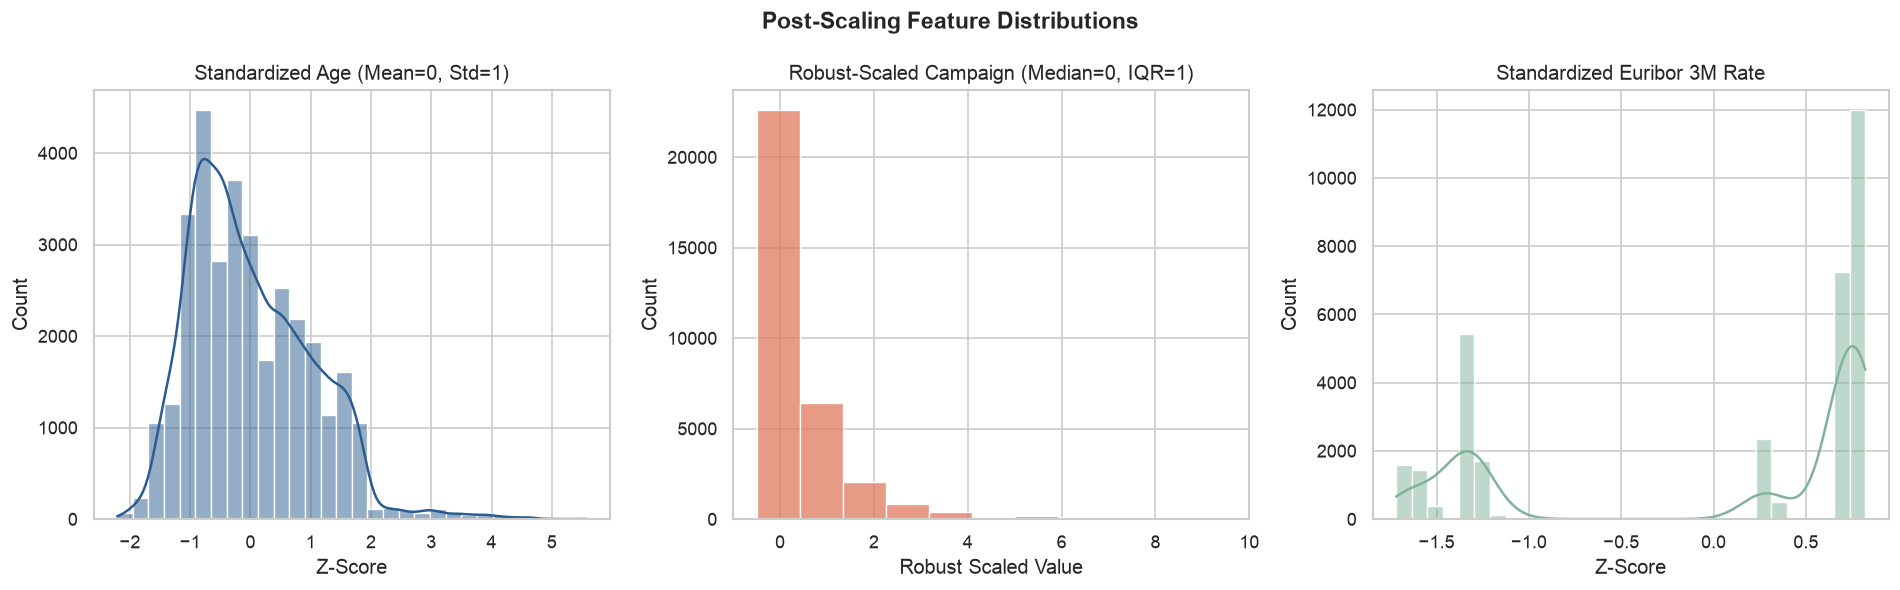

In [8]:
print("Sample of Processed Feature Matrix (First 3 rows, selected columns):")
selected_sample_cols = [
    'education', 'previously_contacted', 'pdays_group_0_to_6_days',
    'pdays_group_not_contacted', 'age_group_<30', 'age_group_60+',
    'campaign', 'euribor3m', 'nr.employed'
]
df_X_train_proc[selected_sample_cols].head(3)

# Diagnostic Plots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Age distribution standardized
sns.histplot(df_X_train_proc['age'], ax=axes[0], kde=True, color='#2b5c8f', bins=30)
axes[0].set_title("Standardized Age (Mean=0, Std=1)")
axes[0].set_xlabel("Z-Score")

# 2. Campaign distribution robust-scaled
sns.histplot(df_X_train_proc['campaign'], ax=axes[1], kde=False, color='#e07a5f', bins=30)
axes[1].set_title("Robust-Scaled Campaign (Median=0, IQR=1)")
axes[1].set_xlabel("Robust Scaled Value")
axes[1].set_xlim(-1, 10)

# 3. Euribor 3-month rate standardized
sns.histplot(df_X_train_proc['euribor3m'], ax=axes[2], kde=True, color='#81b29a', bins=30)
axes[2].set_title("Standardized Euribor 3M Rate")
axes[2].set_xlabel("Z-Score")

plt.suptitle("Post-Scaling Feature Distributions", fontsize=14, weight='bold')
plt.show()

In [9]:
# Create output directory
processed_dir = Path("data/processed") if Path("data").exists() else Path("../data/processed")
processed_dir.mkdir(parents=True, exist_ok=True)

# 1. Save processed feature sets
train_features_path = processed_dir / "X_train_processed.csv"
test_features_path = processed_dir / "X_test_processed.csv"
train_target_path = processed_dir / "y_train.csv"
test_target_path = processed_dir / "y_test.csv"

df_X_train_proc.to_csv(train_features_path, index=False)
df_X_test_proc.to_csv(test_features_path, index=False)
y_train.to_csv(train_target_path, index=False)
y_test.to_csv(test_target_path, index=False)

# 2. Serialize full fitted pipeline
pipeline_save_path = processed_dir / "preprocessor_pipeline.joblib"
joblib.dump(full_pipeline, pipeline_save_path)

# 3. Export feature catalog
metadata = {
    "project": "UCI Bank Marketing Campaign Response",
    "phase": "02_Data_Preprocessing_Pipeline",
    "author": "Athukorala M. B. (IT24101937)",
    "git_branch": "monishka/prepro",
    "total_input_features": X.shape[1],
    "total_output_features": len(feature_names),
    "train_records": len(df_X_train_proc),
    "test_records": len(df_X_test_proc),
    "leakage_feature_dropped": "duration",
    "features_list": list(feature_names)
}

metadata_path = processed_dir / "feature_metadata.json"
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)

print("Export completed successfully:")
print(f" - X_train:  {train_features_path} ({train_features_path.stat().st_size / 1024 / 1024:.2f} MB)")
print(f" - X_test:   {test_features_path} ({test_features_path.stat().st_size / 1024 / 1024:.2f} MB)")
print(f" - y_train:  {train_target_path}")
print(f" - y_test:   {test_target_path}")
print(f" - Pipeline: {pipeline_save_path}")
print(f" - Metadata: {metadata_path}")

Export completed successfully:
 - X_train:  data/processed/X_train_processed.csv (10.98 MB)
 - X_test:   data/processed/X_test_processed.csv (2.75 MB)
 - y_train:  data/processed/y_train.csv
 - y_test:   data/processed/y_test.csv
 - Pipeline: data/processed/preprocessor_pipeline.joblib
 - Metadata: data/processed/feature_metadata.json


In [10]:
# Reload serialized pipeline
loaded_pipeline = joblib.load(pipeline_save_path)

# Take 5 raw samples from X_test (before any transformation)
raw_samples = X_test.head(5)

# Transform using loaded pipeline
transformed_samples = loaded_pipeline.transform(raw_samples)

print(f"Loaded Pipeline Type: {type(loaded_pipeline)}")
print(f"Raw Input Shape:      {raw_samples.shape}")
print(f"Transformed Output:   {transformed_samples.shape}")

# Verify exact numerical match with original transformed test set
original_subset = df_X_test_proc.head(5).to_numpy()
np.testing.assert_allclose(transformed_samples, original_subset, rtol=1e-5, atol=1e-8)
print("Verification Passed: Loaded pipeline transforms raw incoming leads identically!")

Loaded Pipeline Type: <class 'sklearn.pipeline.Pipeline'>
Raw Input Shape:      (5, 19)
Transformed Output:   (5, 64)
Verification Passed: Loaded pipeline transforms raw incoming leads identically!
